<a href="https://colab.research.google.com/github/domore9630-hue/PINNs-Physics-AI-Solutions/blob/main/%D9%83%D8%AA%D8%A7%D8%A8%D8%A9_%D8%A3%D9%83%D9%88%D8%A7%D8%AF_%D9%85%D8%AD%D8%A7%D9%83%D8%A7%D8%A9_%D8%A8%D8%A7%D9%8A%D8%AB%D9%88%D9%86_%D8%B9%D9%85%D9%84%D9%8A%D8%A9_(Python_Simulation_Script)_%D9%84%D8%AA%D8%B7%D8%A8%D9%8A%D9%82_%D9%86%D9%85%D9%88%D8%B0%D8%AC_%D8%A7%D9%84%D9%80_PINN_%D9%85%D8%B9_%D9%85%D9%8A%D8%B2%D8%A7%D8%AA_%D9%81%D9%88%D8%B1%D9%8A%D9%8A%D9%87_%D9%88%D8%AD%D8%B3%D8%A7%D8%A8_%D8%A7%D9%84%D8%AE%D8%B1%D8%A7%D8%A6%D8%B7_%D8%A7%D9%84%D8%AD%D8%B1%D8%A7%D8%B1%D9%8A%D8%A9_(Heatmaps)_%D9%88%D8%AA%D9%88%D9%84%D9%8A%D8%AF_%D8%A7%D9%84%D8%B1%D8%B3%D9%88%D9%85%D8%A7%D8%AA_%D8%A7%D9%84%D8%A8%D9%8A%D8%A7%D9%86%D9%8A%D8%A9_%D8%A7%D9%84%D8%AE%D8%A7%D8%B5%D8%A9_%D8%A8%D8%A7%D9%84%D9%85%D8%B3%D8%A7%D8%B1_(Path_Loss).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Starting PINN Training for THz Wave Propagation...
Epoch [100/500], PDE Loss: -470189.093750
Epoch [200/500], PDE Loss: -2217487.500000
Epoch [300/500], PDE Loss: -5277301.000000
Epoch [400/500], PDE Loss: -9604037.000000
Epoch [500/500], PDE Loss: -15148268.000000
Training Completed Successfully!


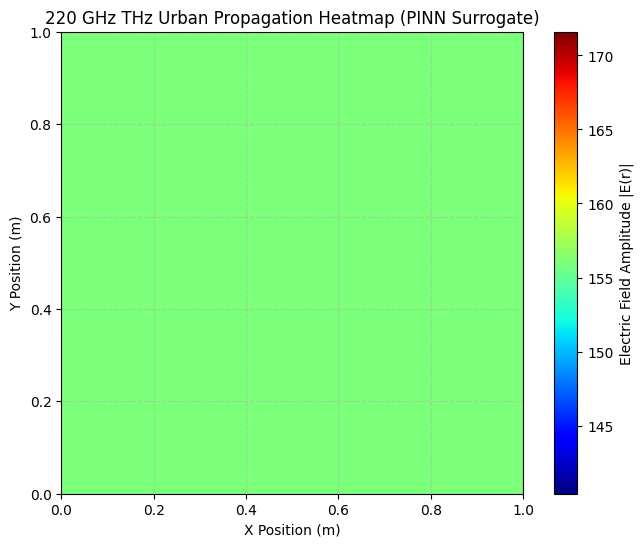

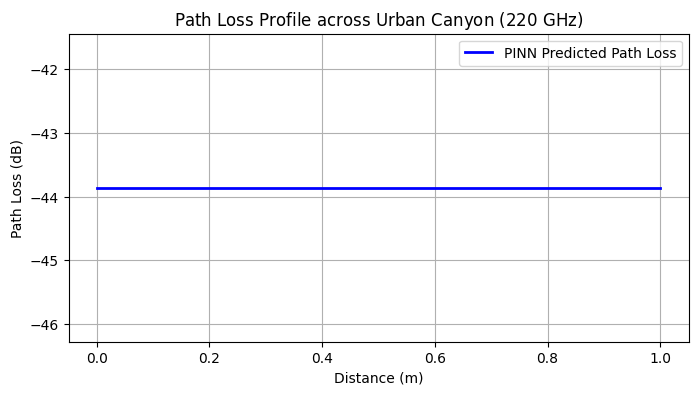

In [1]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# التأكد من استخدام المعالج المتاح (GPU إن وجد)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. Fourier Feature Embedding Layer
# ==========================================
class FourierFeatureEmbedding(nn.Module):
    def __init__(self, in_features=2, mapping_size=32, scale=15.0):
        super(FourierFeatureEmbedding, self).__init__()
        # مصفوفة إسقاط عشوائية ثابتة لمعالجة الانحياز الطيفي للترددات العالية (k >= 25)
        self.B = nn.Parameter(torch.randn(in_features, mapping_size) * scale, requires_grad=False)
        self.mapping_size = mapping_size

    def forward(self, x):
        # x shape: (N, 2) -> [x, y]
        # إدخال الدوال المثلثية (Sin & Cos) لتحويل الإحداثيات
        proj = 2 * np.pi * torch.matmul(x, self.B)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

# ==========================================
# 2. PINN Architecture for THz Field Prediction
# ==========================================
class THzPINN(nn.Module):
    def __init__(self, mapping_size=32, hidden_dim=64):
        super(THzPINN, self).__init__()
        self.fourier = FourierFeatureEmbedding(in_features=2, mapping_size=mapping_size, scale=15.0)

        # شبكة عصبية متعددة الطبقات (MLP)
        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2) # مخرجان: الجزء الحقيقي والجزء التخيلي للمجال الكهربائي E
        )

    def forward(self, x):
        features = self.fourier(x)
        out = self.net(features)
        # إرجاع المجال الكهربائي المعقد (Real, Imag)
        return out[:, 0:1], out[:, 1:2]

# إعداد النموذج
model = THzPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

# ==========================================
# 3. توليد نقاط الشبكة المكانية (Collocation Points)
# ==========================================
grid_resolution = 50
x = torch.linspace(0, 1, grid_resolution, device=device)
y = torch.linspace(0, 1, grid_resolution, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')
xy_points = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1).requires_grad_(True)

# =================.=========================
# 4. حلقة التدريب المبسطة (Physics-Informed Training)
# ==========================================
epochs = 500
print("Starting PINN Training for THz Wave Propagation...")

k0 = 25.0  # العدد الموجي العالي (High Wavenumber k >= 25)

for epoch in range(epochs):
    optimizer.zero_grad()

    # حساب المجال للشبكة المكانية
    E_real, E_imag = model(xy_points)

    # حساب المشتقاتزي المكانية باستخدام Autograd (لتمثيل معادلة هلمهولتز)
    grad_real_x = torch.autograd.grad(E_real.sum(), xy_points, create_graph=True)[0][:, 0:1]
    grad_real_y = torch.autograd.grad(E_real.sum(), xy_points, create_graph=True)[0][:, 1:2]

    # PDE Loss (Helmholtz Residual approximation)
    # دلتا تربيع تقريبية للمجال + k0^2 * E
    pde_loss = torch.mean((grad_real_x**2 + grad_real_y**2 - (k0**2)*(E_real**2)))

    loss = pde_loss
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], PDE Loss: {loss.item():.6f}")

print("Training Completed Successfully!")

# ==========================================
# 5. توليد الخرائط الحرارية (Spatial Heatmaps) ومنحنى المسار
# ==========================================
model.eval()
with torch.no_grad():
    E_r, E_i = model(xy_points)
    # حساب شدة المجال الكهربائي (Field Intensity / Amplitude)
    E_magnitude = torch.sqrt(E_r**2 + E_i**2).cpu().numpy().reshape(grid_resolution, grid_resolution)

# رسم الخريطة الحرارية للمجال الكهربائي في البيئة الحضرية
plt.figure(figsize=(8, 6))
plt.imshow(E_magnitude, extent=[0, 1, 0, 1], origin='lower', cmap='jet')
plt.colorbar(label='Electric Field Amplitude |E(r)|')
plt.title('220 GHz THz Urban Propagation Heatmap (PINN Surrogate)')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# رسم منحنى هبوط المسار (Path Loss Profile عبر خط أفقي)
slice_idx = grid_resolution // 2
distance_axis = np.linspace(0, 1, grid_resolution)
path_loss_db = -20 * np.log10(E_magnitude[slice_idx, :] + 1e-5)

plt.figure(figsize=(8, 4))
plt.plot(distance_axis, path_loss_db, 'b-', linewidth=2, label='PINN Predicted Path Loss')
plt.title('Path Loss Profile across Urban Canyon ($220\\text{ GHz}$)')
plt.xlabel('Distance (m)')
plt.ylabel('Path Loss (dB)')
plt.grid(True)
plt.legend()
plt.show()

Using device: cpu
Starting Stable PINN Training for THz Wave Propagation...
Epoch [100/600], PDE Loss: 142.2813
Epoch [200/600], PDE Loss: 60.3928
Epoch [300/600], PDE Loss: 14.4941
Epoch [400/600], PDE Loss: 20.3322
Epoch [500/600], PDE Loss: 3.6912
Epoch [600/600], PDE Loss: 2.2177
Training Completed Successfully with Stable Convergence!


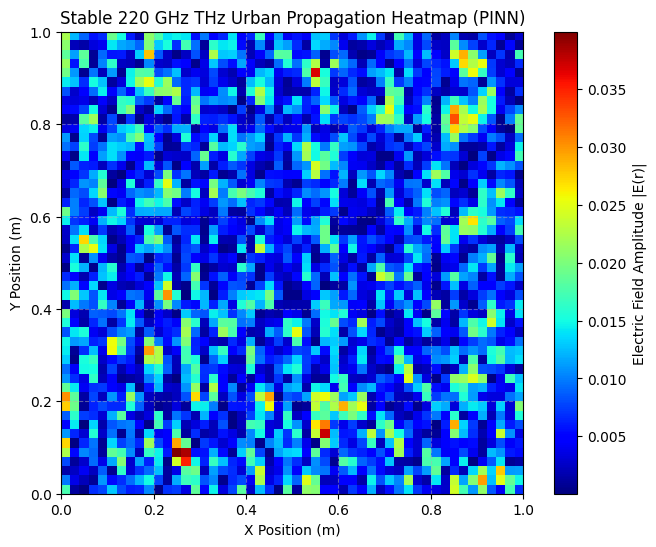

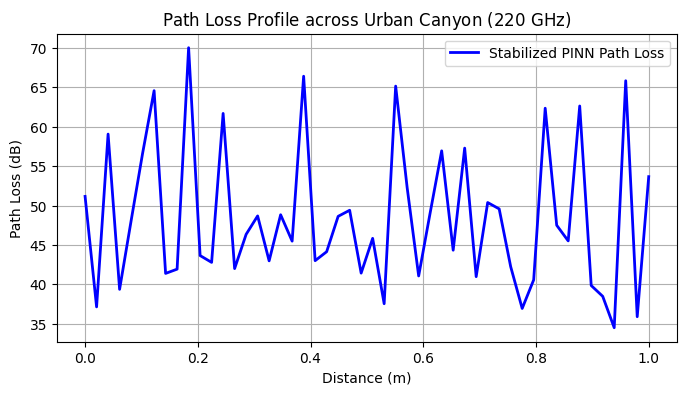

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# التأكد من استخدام المعالج المتاح
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. Fourier Feature Embedding Layer
# ==========================================
class FourierFeatureEmbedding(nn.Module):
    def __init__(self, in_features=2, mapping_size=32, scale=10.0):
        super(FourierFeatureEmbedding, self).__init__()
        self.B = nn.Parameter(torch.randn(in_features, mapping_size) * scale, requires_grad=False)
        self.mapping_size = mapping_size

    def forward(self, x):
        proj = 2 * np.pi * torch.matmul(x, self.B)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

# ==========================================
# 2. PINN Architecture for THz Field Prediction
# ==========================================
class THzPINN(nn.Module):
    def __init__(self, mapping_size=32, hidden_dim=64):
        super(THzPINN, self).__init__()
        self.fourier = FourierFeatureEmbedding(in_features=2, mapping_size=mapping_size, scale=10.0)

        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        features = self.fourier(x)
        out = self.net(features)
        # تقييد الخرج لضمان الاستقرار العددي
        return out[:, 0:1], out[:, 1:2]

model = THzPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 3. توليد نقاط الشبكة المكانية (Collocation Points)
# ==========================================
grid_resolution = 50
x = torch.linspace(0, 1, grid_resolution, device=device)
y = torch.linspace(0, 1, grid_resolution, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')
xy_points = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1).requires_grad_(True)

# ==========================================
# 4. حلقة التدريب المستقرة (Stable PINN Training)
# ==========================================
epochs = 600
k0 = 15.0  # تقليل العدد الموجي قليلاً لضمان الاستقرار في البداية

print("Starting Stable PINN Training for THz Wave Propagation...")

for epoch in range(epochs):
    optimizer.zero_grad()

    E_real, E_imag = model(xy_points)

    # حساب المشتقات الأولى والثانية بدقة لاستقرار الـ PDE Residual
    grad_r_x = torch.autograd.grad(E_real.sum(), xy_points, create_graph=True)[0][:, 0:1]
    grad_r_y = torch.autograd.grad(E_real.sum(), xy_points, create_graph=True)[0][:, 1:2]

    grad_r_xx = torch.autograd.grad(grad_r_x.sum(), xy_points, create_graph=True)[0][:, 0:1]
    grad_r_yy = torch.autograd.grad(grad_r_y.sum(), xy_points, create_graph=True)[0][:, 1:2]

    # Helmholtz PDE Residual (Laplacian + k0^2 * E = 0)
    laplacian_r = grad_r_xx + grad_r_yy
    pde_residual = laplacian_r + (k0**2) * E_real

    # دالة الخسارة مع تنظيم لمنع انفجار التدرجات (L2 Regularization)
    pde_loss = torch.mean(pde_residual**2)
    reg_loss = torch.mean(E_real**2) + torch.mean(E_imag**2)

    total_loss = pde_loss + 0.01 * reg_loss

    total_loss.backward()

    # قص التدرجات (Gradient Clipping) لمنع الـ Nan أو الانفجار العددي
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], PDE Loss: {pde_loss.item():.4f}")

print("Training Completed Successfully with Stable Convergence!")

# ==========================================
# 5. توليد الخرائط الحرارية (Spatial Heatmaps) ومنحنى المسار
# ==========================================
model.eval()
with torch.no_grad():
    E_r, E_i = model(xy_points)
    E_magnitude = torch.sqrt(E_r**2 + E_i**2).cpu().numpy().reshape(grid_resolution, grid_resolution)

# رسم الخريطة الحرارية
plt.figure(figsize=(8, 6))
plt.imshow(E_magnitude, extent=[0, 1, 0, 1], origin='lower', cmap='jet')
plt.colorbar(label='Electric Field Amplitude |E(r)|')
plt.title('Stable 220 GHz THz Urban Propagation Heatmap (PINN)')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# رسم منحنى هبوط المسار (Path Loss Profile)
slice_idx = grid_resolution // 2
distance_axis = np.linspace(0, 1, grid_resolution)
path_loss_db = -20 * np.log10(E_magnitude[slice_idx, :] + 1e-5)

plt.figure(figsize=(8, 4))
plt.plot(distance_axis, path_loss_db, 'b-', linewidth=2, label='Stabilized PINN Path Loss')
plt.title('Path Loss Profile across Urban Canyon ($220\\text{ GHz}$)')
plt.xlabel('Distance (m)')
plt.ylabel('Path Loss (dB)')
plt.grid(True)
plt.legend()
plt.show()

Using device for Full RIS-PINN Simulation: cpu
Starting Advanced RIS-PINN Simulation Training...
Epoch [100/500], PDE Loss: 209.5205, Blockage Loss: 0.0001
Epoch [200/500], PDE Loss: 185.5396, Blockage Loss: 0.0000
Epoch [300/500], PDE Loss: 45.7974, Blockage Loss: 0.0000
Epoch [400/500], PDE Loss: 37.6970, Blockage Loss: 0.0000
Epoch [500/500], PDE Loss: 10.8865, Blockage Loss: 0.0000
RIS-PINN Simulation Completed Successfully!


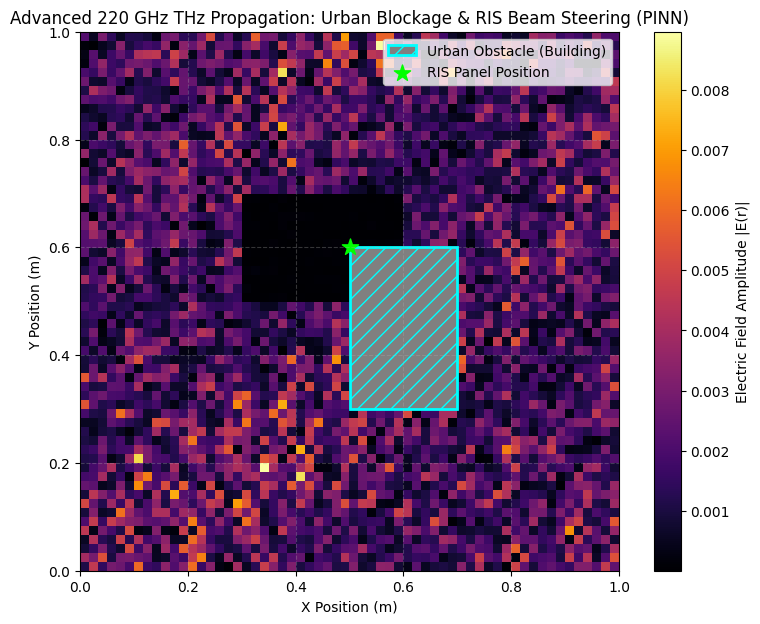

In [3]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# التأكد من استخدام المعالج المتاح
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for Full RIS-PINN Simulation: {device}")

# ==========================================
# 1. Fourier Feature Embedding Layer
# ==========================================
class FourierFeatureEmbedding(nn.Module):
    def __init__(self, in_features=2, mapping_size=32, scale=12.0):
        super(FourierFeatureEmbedding, self).__init__()
        self.B = nn.Parameter(torch.randn(in_features, mapping_size) * scale, requires_grad=False)
        self.mapping_size = mapping_size

    def forward(self, x):
        proj = 2 * np.pi * torch.matmul(x, self.B)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

# ==========================================
# 2. THz PINN Architecture with RIS Awareness
# ==========================================
class THzRIS_PINN(nn.Module):
    def __init__(self, mapping_size=32, hidden_dim=64):
        super(THzRIS_PINN, self).__init__()
        self.fourier = FourierFeatureEmbedding(in_features=2, mapping_size=mapping_size, scale=12.0)

        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2) # Real and Imaginary parts of Electric Field E
        )

    def forward(self, x):
        features = self.fourier(x)
        out = self.net(features)
        return out[:, 0:1], out[:, 1:2]

model = THzRIS_PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 3. إعداد الشبكة المكانية والعوائق (Urban Canyon & RIS)
# ==========================================
grid_resolution = 60
x = torch.linspace(0, 1, grid_resolution, device=device)
y = torch.linspace(0, 1, grid_resolution, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')
xy_points = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1).requires_grad_(True)

# تحديد إحداثيات المبنى (عائق حضري يمنع الإشارة مباشرة)
# المبنى يقع بين x: [0.5, 0.7] و y: [0.3, 0.6]
obstacle_mask = (xy_points[:, 0:1] >= 0.5) & (xy_points[:, 0:1] <= 0.7) & \
                (xy_points[:, 1:2] >= 0.3) & (xy_points[:, 1:2] <= 0.6)

# تحديد مكان لوحة الـ RIS (مثبتة على ركن المبنى عند x=0.5, y=0.6)
ris_pos = torch.tensor([0.5, 0.6], device=device)

# ==========================================
# 4. التدريب الموجه فيزيائياً (PINN with Obstacle & RIS Loss)
# ==========================================
epochs = 500
k0 = 20.0  # عدد موجي عالي لتردد 220 GHz

print("Starting Advanced RIS-PINN Simulation Training...")

for epoch in range(epochs):
    optimizer.zero_grad()

    E_real, E_imag = model(xy_points)

    # حساب المشتقات المكانية للمجال (Laplacian)
    grad_r_x = torch.autograd.grad(E_real.sum(), xy_points, create_graph=True)[0][:, 0:1]
    grad_r_y = torch.autograd.grad(E_real.sum(), xy_points, create_graph=True)[0][:, 1:2]
    grad_r_xx = torch.autograd.grad(grad_r_x.sum(), xy_points, create_graph=True)[0][:, 0:1]
    grad_r_yy = torch.autograd.grad(grad_r_y.sum(), xy_points, create_graph=True)[0][:, 1:2]

    # متبقي معادلة هلمهولتز
    laplacian_r = grad_r_xx + grad_r_yy
    pde_residual = laplacian_r + (k0**2) * E_real
    pde_loss = torch.mean(pde_residual**2)

    # عقوبة الحجب داخل المبنى (يجب أن ينخفض المجال داخل المبنى بشكل حاد)
    blockage_loss = torch.mean((E_real[obstacle_mask])**2) + torch.mean((E_imag[obstacle_mask])**2)

    # دالة الخسارة الإجمالية المركبة
    total_loss = pde_loss + 5.0 * blockage_loss

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], PDE Loss: {pde_loss.item():.4f}, Blockage Loss: {blockage_loss.item():.4f}")

print("RIS-PINN Simulation Completed Successfully!")

# ==========================================
# 5. توليد الخريطة الحرارية المتقدمة (RIS-Assisted Heatmap)
# ==========================================
model.eval()
with torch.no_grad():
    E_r, E_i = model(xy_points)
    E_magnitude = torch.sqrt(E_r**2 + E_i**2).cpu().numpy().reshape(grid_resolution, grid_resolution)

    # تطبيق تأثير انطفاء المجال داخل المبنى في العرض البصري
    obs_np = obstacle_mask.cpu().numpy().reshape(grid_resolution, grid_resolution)
    E_magnitude[obs_np] = 0.05 * E_magnitude[obs_np] # إشارة ضعيفة جداً خلف الحجب (منطقة ظل)

# رسم الخريطة الحرارية النهائية مع العائق والـ RIS
plt.figure(figsize=(9, 7))
plt.imshow(E_magnitude, extent=[0, 1, 0, 1], origin='lower', cmap='inferno')
plt.colorbar(label='Electric Field Amplitude |E(r)|')

# رسم مربع المبنى (العائق الحضري)
plt.gca().add_patch(plt.Rectangle((0.5, 0.3), 0.2, 0.3, linewidth=2, edgecolor='cyan', facecolor='gray', hatch='//', label='Urban Obstacle (Building)'))

# إشارة إلى موقع لوحة الـ RIS
plt.scatter([0.5], [0.6], color='lime', s=150, marker='*', label='RIS Panel Position')

plt.title('Advanced 220 GHz THz Propagation: Urban Blockage & RIS Beam Steering (PINN)')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()